In [ ]:
%load_ext autoreload
%autoreload 2


## Load the data Unet+Effb1

In [ ]:
# Data Collection has been refactored into src/data/collection.py
# To run data collection, run:
# !python main.py --data

from src.config import Config
from src.data.collection import check_tbx11k_availability, process_tbx11k_images

config = Config()
config.create_dirs()
print('Project structure initialized successfully.')


model

In [2]:
!pip install -q opencv-python
!pip install -q U albumentations
!pip install -q segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 117.3 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 88.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 34.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 15.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 9.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 95.6 MB/s eta 0:00:00:00:0100:01


In [ ]:
# The monolithic ML pipeline has been refactored into the src/ module.
# Core components are now accessible separately:

# 1. Models and Losses
from src.models.architectures import UNetSegmentationModel, DomainRobustClassifier
from src.models.losses import BalancedFocalLoss, coral_loss

# 2. Datasets
from src.data.dataset import MixedDomainDataset, TwoStreamBatchSampler

# 3. Training & Evaluation
from src.training.pipeline import TBPipeline
from src.evaluation.visualization import PatientVisualizationPipeline

print('src/ package imported successfully!')

# To run the full pipeline:
# pipeline = TBPipeline(config)
# final_model = pipeline.execute()


Loading models on device: cuda
Classification model loaded successfully
Segmentation model loaded successfully
Creating example visualizations for each disease class...

Visualizing example from Lung_Cancer folder

Processing: VinBigData_26d1d5a0ef2e692c6340e74859ffdc53_20250914041937831.png
Visualization saved to: ./example_lung_cancer_pipeline.png


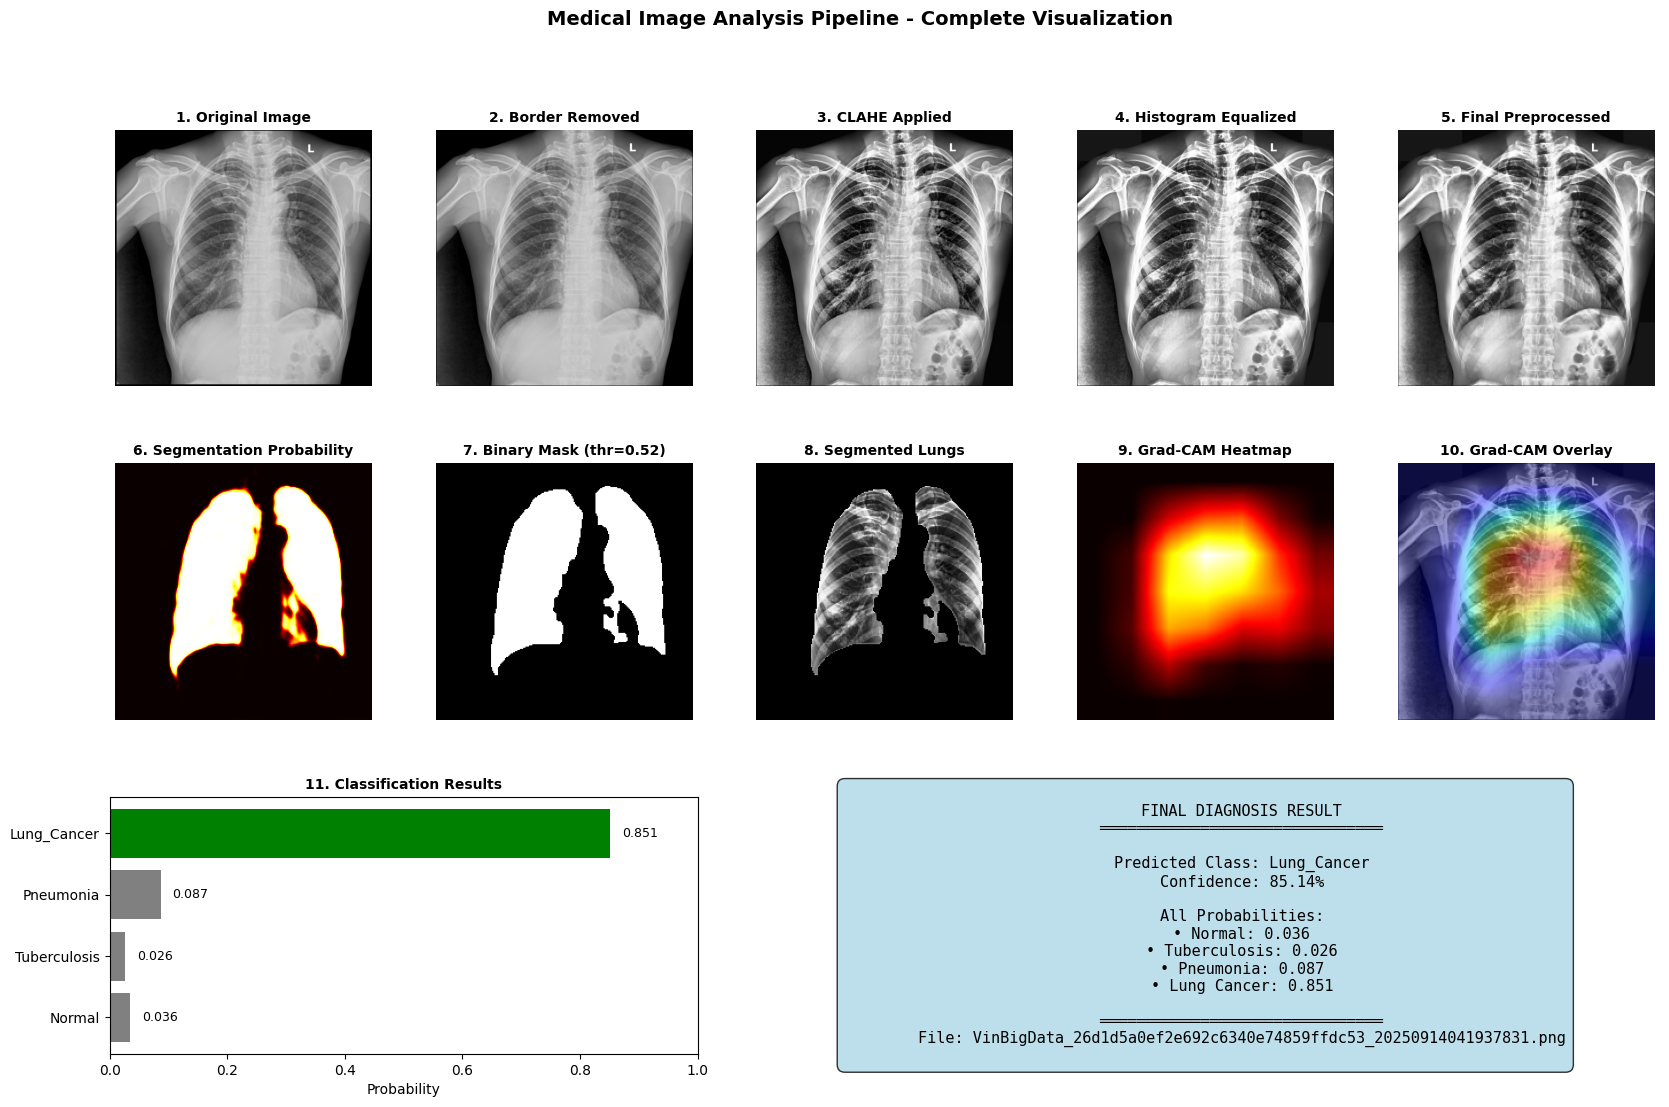

True Label: Lung_Cancer
Predicted: Lung_Cancer
Correct: ✓
Confidence: 85.14%

Visualizing example from Normal folder

Processing: TB_Normal-2651_20250914041824066.png
Visualization saved to: ./example_normal_pipeline.png


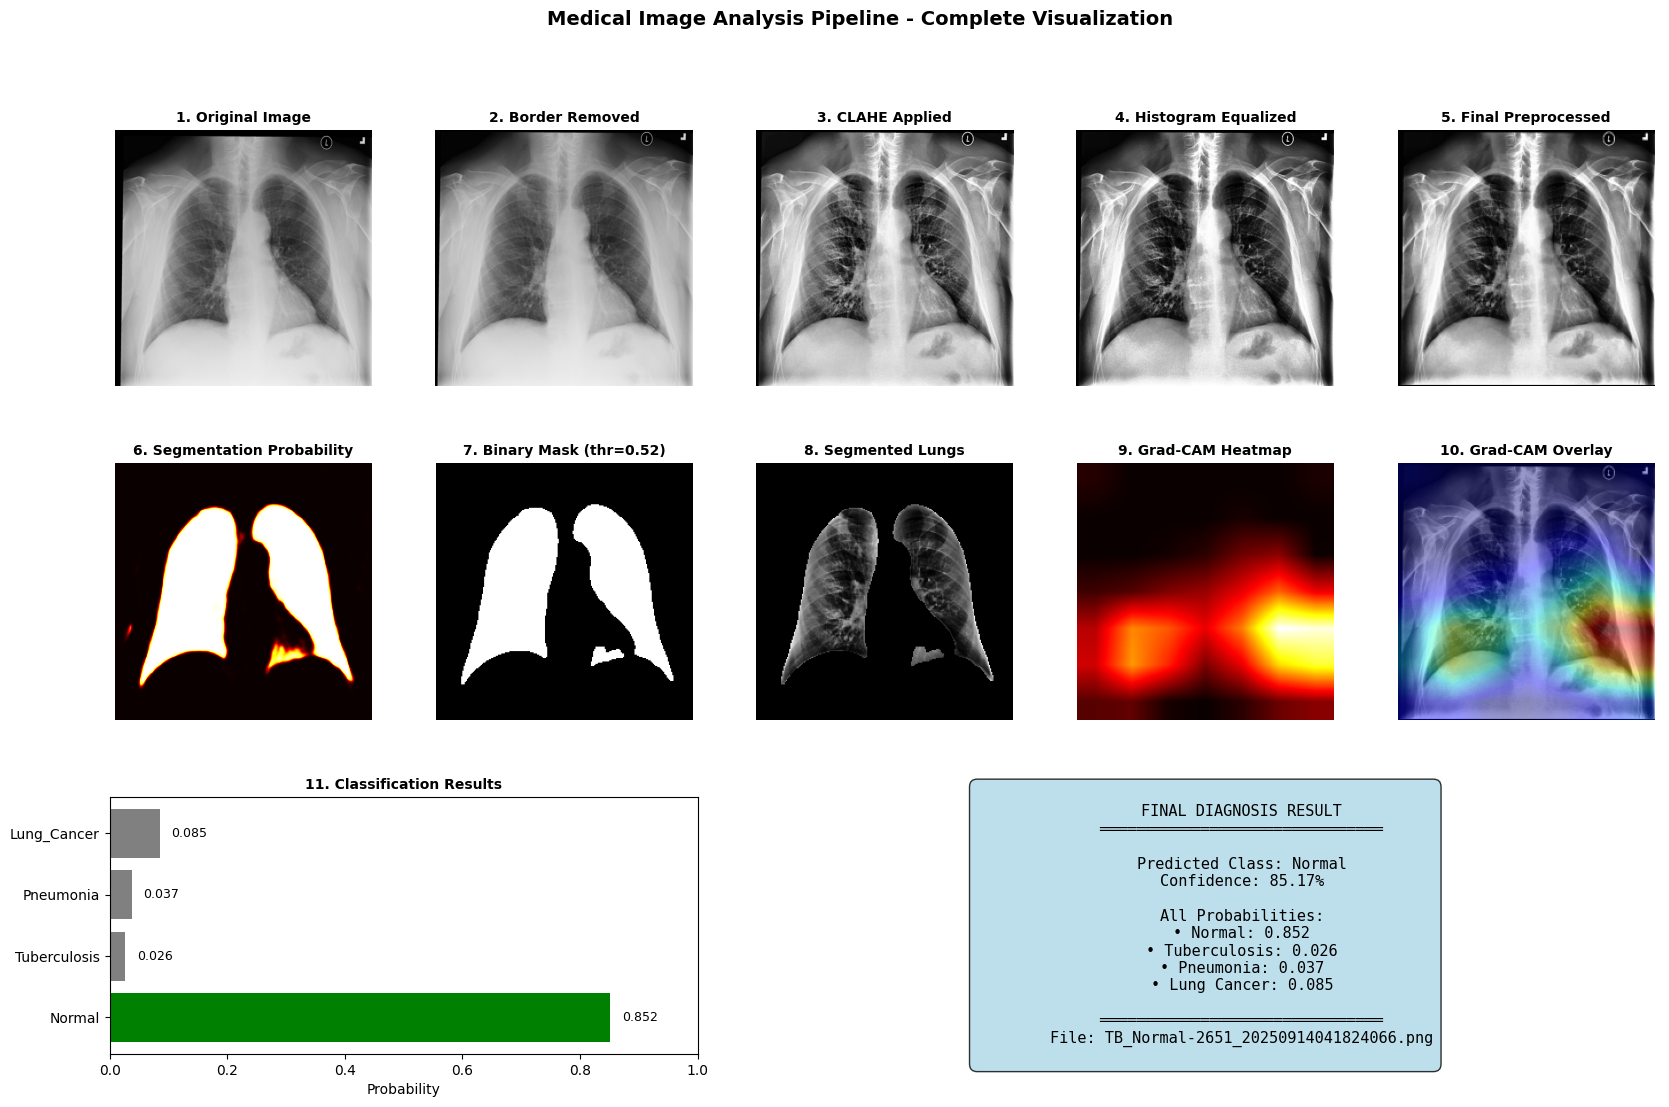

True Label: Normal
Predicted: Normal
Correct: ✓
Confidence: 85.17%

Visualizing example from Pneumonia folder

Processing: NIH_00000766_005_20250914041758387.png
Visualization saved to: ./example_pneumonia_pipeline.png


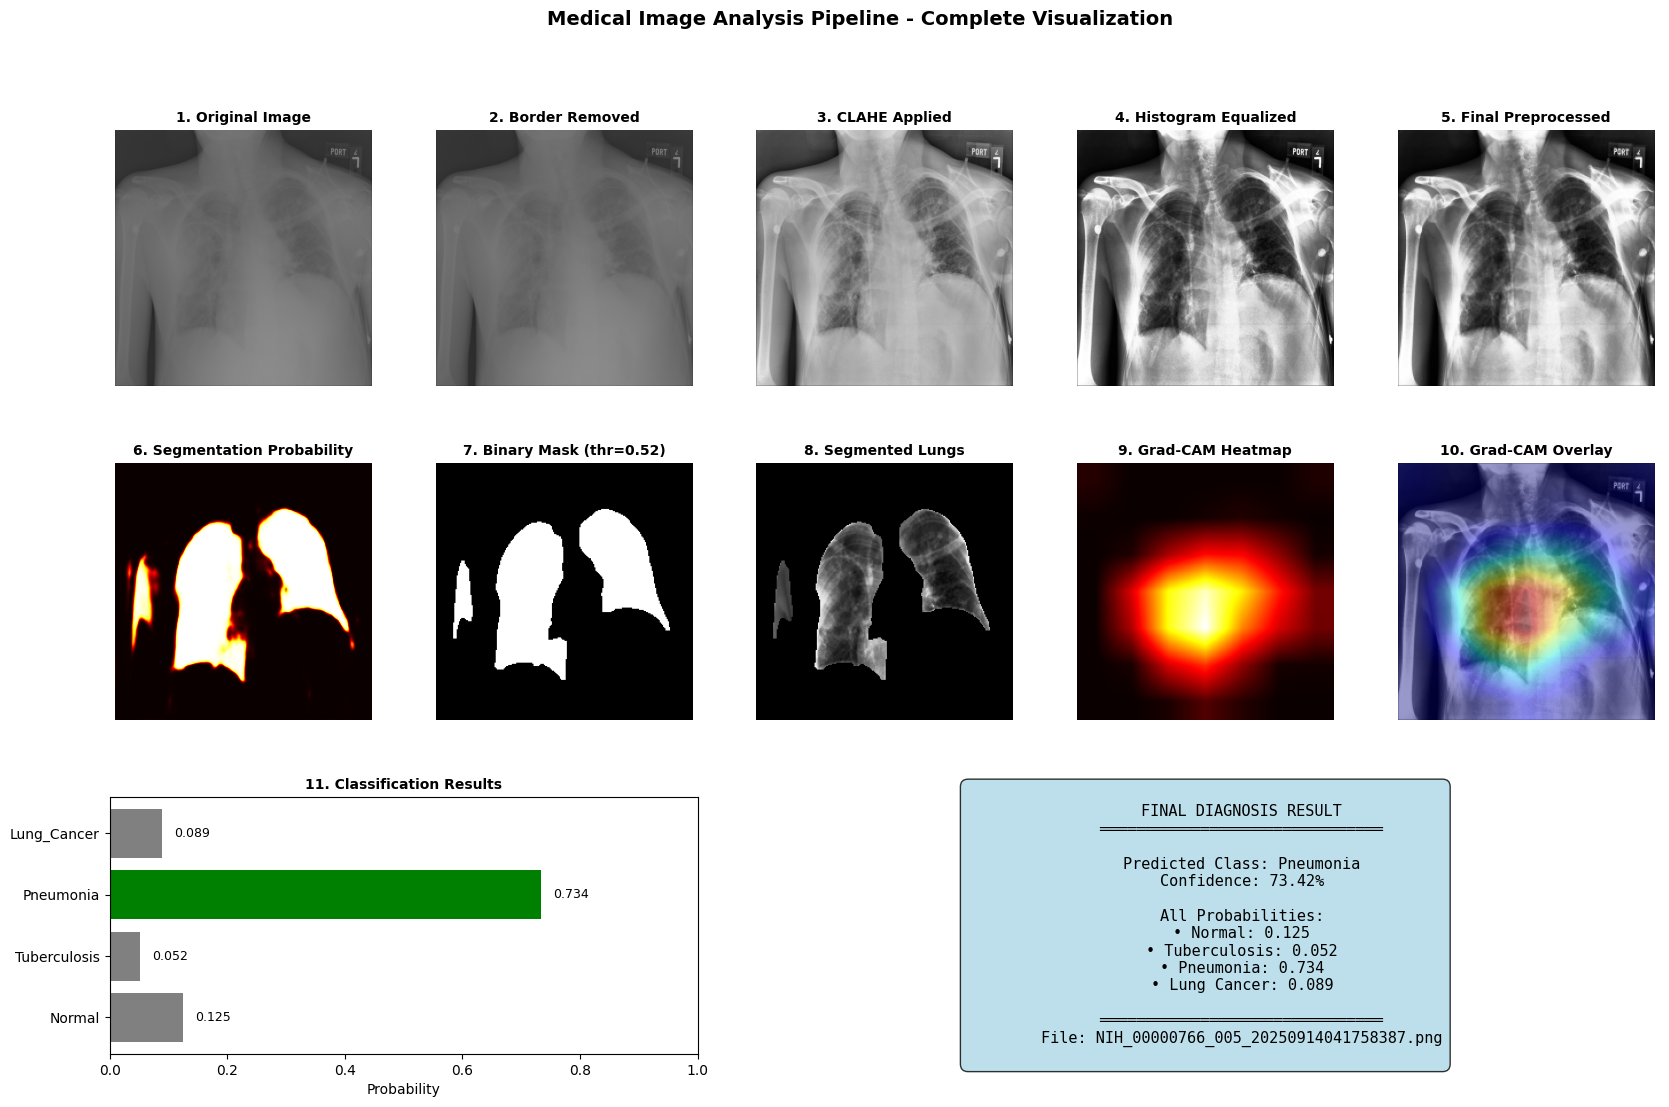

True Label: Pneumonia
Predicted: Pneumonia
Correct: ✓
Confidence: 73.42%

Visualizing example from Tuberculosis folder

Processing: TBX11K_tb0373_20250914041826919.png
Visualization saved to: ./example_tuberculosis_pipeline.png


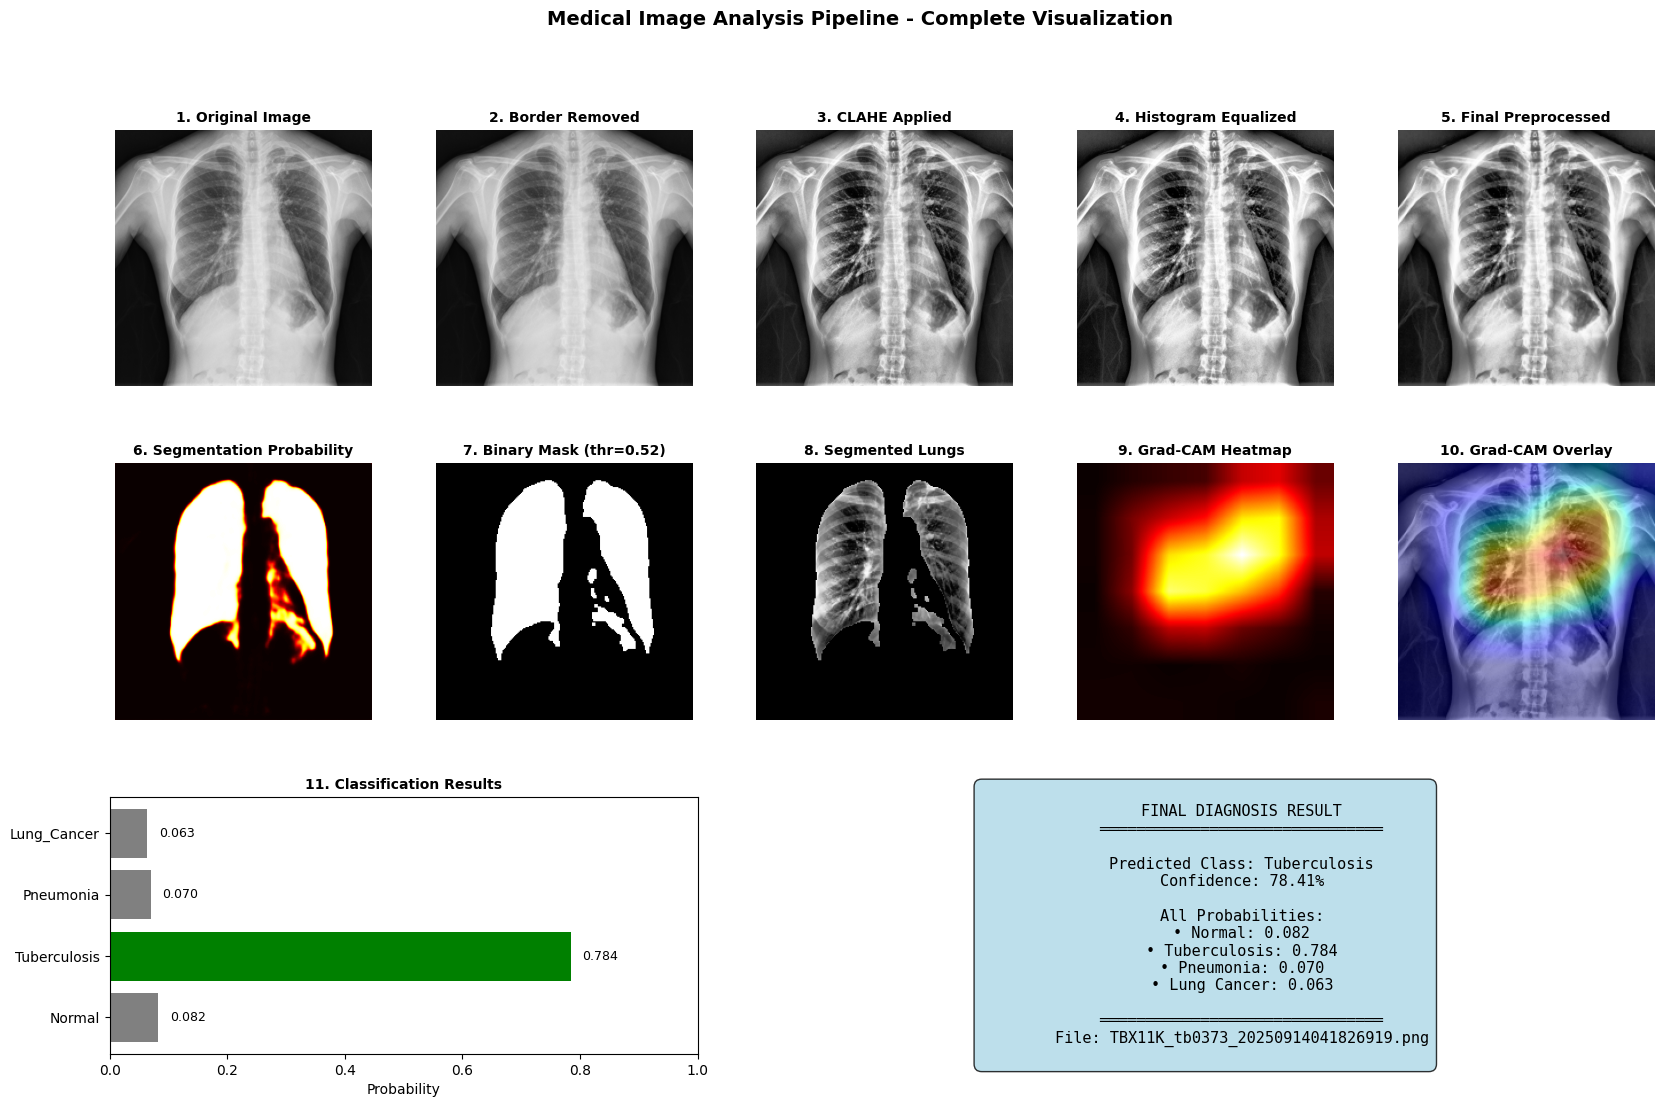

True Label: Tuberculosis
Predicted: Tuberculosis
Correct: ✓
Confidence: 78.41%

Finding misclassified cases...

Found 0 misclassified cases
Visualizing misclassified examples...

Creating comparison grid...
No images found for pneumonia

✅ All visualizations complete!


In [13]:
# Integration with your existing code

from pathlib import Path
import torch

# Your existing paths
BASE_PATH = Path('/kaggle/working/chest_xray_test_v2')
CLS_MODEL_PATH = Path('/kaggle/input/weight-gpt5/best_classification_model.pth')
SEG_MODEL_PATH = Path('/kaggle/input/weight-gpt5/best_segmentation_model.pth')

# Initialize the visualization predictor
viz_predictor = VisualizationPredictor(
    classification_model_path=str(CLS_MODEL_PATH),
    segmentation_model_path=str(SEG_MODEL_PATH),
    output_dir='./visualization_results',
    device='cuda' if torch.cuda.is_available() else 'cpu',
    mask_threshold=0.52
)

# Example 1: Process and visualize a single image
def visualize_single_example(image_path):
    """Process and visualize a single X-ray image"""
    
    # Generate complete visualization
    results = viz_predictor.visualize_complete_pipeline(
        image_path,
        save_path=f'./viz_complete_{Path(image_path).stem}.png'
    )
    
    # Also create compact version
    pred_class, confidence = viz_predictor.create_compact_visualization(
        image_path,
        save_path=f'./viz_compact_{Path(image_path).stem}.png'
    )
    
    print(f"Predicted: {pred_class} ({confidence:.1%} confidence)")
    return results

# Example 2: Visualize examples from each class
def visualize_class_examples():
    """Visualize one example from each disease class"""
    
    test_folders = {
        'lung_cancer': 'Lung_Cancer',
        'normal': 'Normal', 
        'pneumonia': 'Pneumonia',
        'tuberculosis': 'Tuberculosis'
    }
    
    for folder_name, true_label in test_folders.items():
        folder_path = BASE_PATH / folder_name
        
        # Get first image from folder
        image_files = list(folder_path.glob('*.jpg')) + list(folder_path.glob('*.png'))
        
        if image_files:
            print(f"\n{'='*60}")
            print(f"Visualizing example from {true_label} folder")
            print('='*60)
            
            # Process first image
            image_path = image_files[0]
            results = viz_predictor.visualize_complete_pipeline(
                str(image_path),
                save_path=f'./example_{folder_name}_pipeline.png'
            )
            
            # Check if prediction is correct
            pred_class = results['predicted_class']
            is_correct = pred_class == true_label
            
            print(f"True Label: {true_label}")
            print(f"Predicted: {pred_class}")
            print(f"Correct: {'✓' if is_correct else '✗'}")
            print(f"Confidence: {results['confidence']:.2%}")

# Example 3: Batch process with visualization for misclassified cases
def visualize_misclassified_cases(num_examples=2):
    """Find and visualize misclassified cases"""
    
    misclassified = []
    
    for folder_name in ['lung_cancer', 'normal', 'pneumonia', 'tuberculosis']:
        folder_path = BASE_PATH / folder_name
        true_label = folder_name.replace('_', ' ').title()
        
        # Process images
        for img_path in list(folder_path.glob('*.jpg'))[:10]:  # Check first 10
            # Quick prediction without full visualization
            result = viz_predictor.visualize_complete_pipeline(
                str(img_path),
                save_path=None  # Don't save yet
            )
            
            if result['predicted_class'] != true_label:
                misclassified.append({
                    'path': img_path,
                    'true': true_label,
                    'pred': result['predicted_class'],
                    'conf': result['confidence']
                })
    
    # Visualize the misclassified cases
    print(f"\nFound {len(misclassified)} misclassified cases")
    print("Visualizing misclassified examples...")
    
    for i, case in enumerate(misclassified[:num_examples]):
        print(f"\nMisclassified Case {i+1}:")
        print(f"True: {case['true']}, Predicted: {case['pred']} ({case['conf']:.1%})")
        
        # Create detailed visualization
        viz_predictor.visualize_complete_pipeline(
            str(case['path']),
            save_path=f'./misclassified_{i+1}_full.png'
        )
        
        # Create compact visualization
        viz_predictor.create_compact_visualization(
            str(case['path']),
            save_path=f'./misclassified_{i+1}_compact.png'
        )

# Example 4: Create comparison grid for a specific disease
def create_disease_comparison(disease='pneumonia', num_samples=4):
    """Create a comparison grid showing multiple examples of one disease"""
    
    import matplotlib.pyplot as plt
    from matplotlib.gridspec import GridSpec
    
    folder_path = BASE_PATH / disease
    image_files = list(folder_path.glob('*.jpg'))[:num_samples]
    
    if not image_files:
        print(f"No images found for {disease}")
        return
    
    # Create figure with subplots
    fig = plt.figure(figsize=(20, 5*num_samples))
    gs = GridSpec(num_samples, 6, figure=fig, hspace=0.3, wspace=0.2)
    
    for idx, img_path in enumerate(image_files):
        # Process image
        original = np.array(Image.open(img_path).convert('RGB'))
        preprocessed = viz_predictor.preprocessor.process_image(original)
        segmented, mask, _ = viz_predictor.apply_segmentation_with_viz(preprocessed)
        
        # Get prediction
        augmented = viz_predictor.cls_transform(image=segmented)
        img_tensor = augmented['image'].unsqueeze(0).to(viz_predictor.device)
        
        with torch.no_grad():
            outputs = viz_predictor.classifier(img_tensor)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()[0]
            pred_idx = np.argmax(probs)
        
        pred_class = viz_predictor.class_names[pred_idx]
        
        # Generate Grad-CAM
        gradcam = viz_predictor.generate_gradcam(segmented, pred_idx)
        overlay = viz_predictor.create_heatmap_overlay(preprocessed, gradcam)
        
        # Plot row
        axes = [fig.add_subplot(gs[idx, col]) for col in range(6)]
        
        axes[0].imshow(original)
        axes[0].set_title('Original', fontsize=9)
        
        axes[1].imshow(preprocessed)
        axes[1].set_title('Preprocessed', fontsize=9)
        
        axes[2].imshow(mask, cmap='gray')
        axes[2].set_title('Mask', fontsize=9)
        
        axes[3].imshow(segmented)
        axes[3].set_title('Segmented', fontsize=9)
        
        axes[4].imshow(overlay)
        axes[4].set_title('Grad-CAM', fontsize=9)
        
        # Prediction text
        axes[5].text(0.5, 0.5, f'{pred_class}\n{probs[pred_idx]:.1%}',
                    ha='center', va='center', fontsize=11,
                    color='green' if pred_class == disease.title() else 'red')
        axes[5].set_title('Prediction', fontsize=9)
        
        for ax in axes:
            ax.axis('off')
    
    fig.suptitle(f'{disease.upper()} Disease Analysis - {num_samples} Samples', 
                fontsize=14, fontweight='bold')
    
    plt.savefig(f'./{disease}_comparison_grid.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Comparison grid saved for {disease}")

# Run examples
if __name__ == "__main__":
    # 1. Visualize one example from each class
    print("Creating example visualizations for each disease class...")
    visualize_class_examples()
    
    # 2. Find and visualize misclassified cases
    print("\n" + "="*60)
    print("Finding misclassified cases...")
    visualize_misclassified_cases(num_examples=2)
    
    # 3. Create comparison grid for pneumonia
    print("\n" + "="*60)
    print("Creating comparison grid...")
    create_disease_comparison('pneumonia', num_samples=3)
    
    print("\n✅ All visualizations complete!")